# **Lab 6**

In this lab, we will perform some simple analysis on the most basic 1-channel EEG. The data used in this lab is collected on the forehead of a human subject resting and doing nothing vs laughing while watching comedy sketches. We will apply some simple signal processing steps to transform the data into the frequency domain, and compare the frequency sub-bands of the two data.

Please follow the code to finish the lab and submit a report based on the provided teamplate on Canvas.

In [1]:
# Scientific packages
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

**Step 1: Research brain wave bands**
First, define the frequencies for each brain wave band using a reputable source. Also note down what brain function that each frequency band represents in the lab report.

In [2]:
# TODO: Do an online search for the frequency of different brainwave bands

# Delta Band
d_band = [0.5, 4] # deep sleep

# Theta Band
t_band = [4, 8] # drowsiness and meditation

# Alpha Band
a_band = [8, 13] # relaxed and resting

# Beta Band
b_band = [13, 30] # active thinking and focus

# Gamma Band
g_band = [30, 100] # heavy thinking and problem-solving


**Step 2: Load the raw data**
Load the resting EEG data, which is taken when the subject was sitting comfortably in a resting state, performing no active cognitive or motor tasks, with eyes open and an undirected forward gaze. Plot the raw EEG signal.

In [3]:
# Sampling frequency of acquired data
fs = 1000 # 1000Hz

# TODO: Load raw data
raw = np.genfromtxt('EEG_ref.txt', usecols=5)

# TODO: Generate the time axis of the signal given its sampling frequency
# hint: length of time and signal should be the same, each 2 timestamps differ by 1/fs
# make sure to convert to numpy array
time = np.arange(len(raw)) / fs

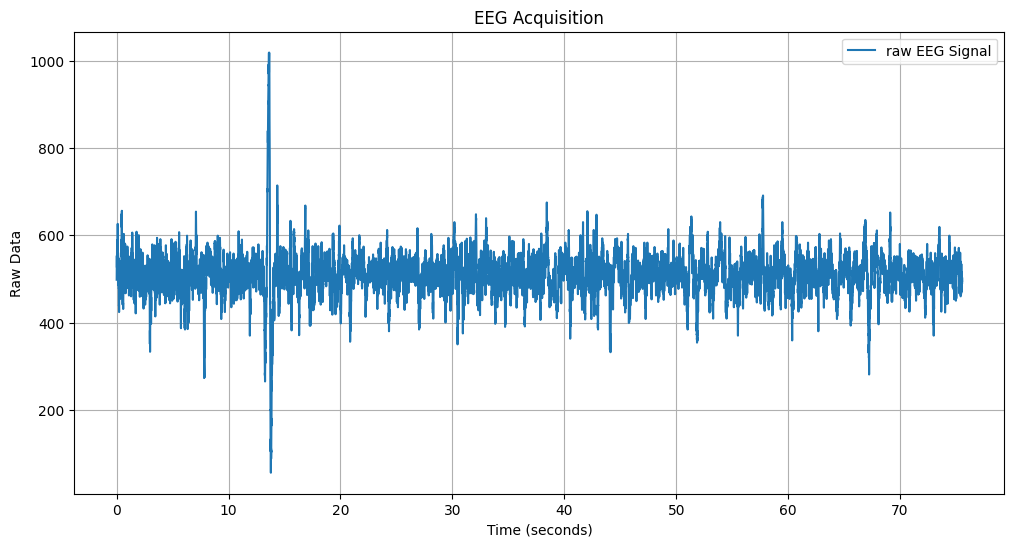

In [4]:
# Plotting the raw EEG signal
plt.figure(figsize=(12, 6))
plt.plot(time, raw, label='raw EEG Signal')
plt.xlabel('Time (seconds)')
plt.ylabel('Raw Data')
plt.title('EEG Acquisition')
plt.legend()
plt.grid(True)
plt.show()

**Step 3: Bandpass filter**
Filter the raw data according to the typical EEG range (i.e., frequency range that covers all brain wave bands).

In [5]:
# TODO: Bandpass filter the signal according to typical EEG range
lowcut = 0.5
highcut = 50.0 

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    data_centered = data - np.mean(data)
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    sos = signal.butter(order, [low, high], btype='band', output='sos')
    y = signal.sosfiltfilt(sos, data_centered)
    return y

filtered_signal = bandpass_filter(raw, lowcut, highcut, fs)

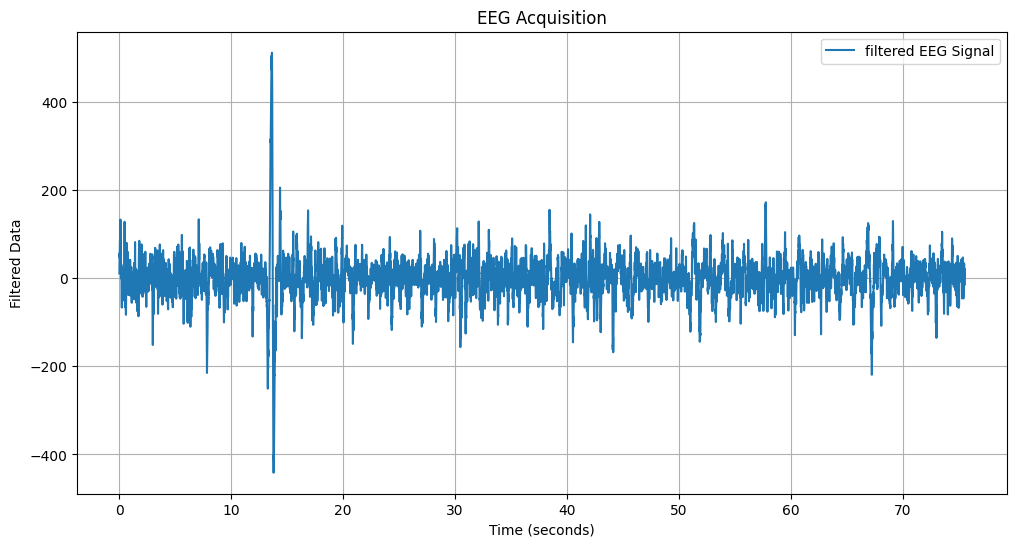

In [6]:
# Plotting the filtered EEG signal
plt.figure(figsize=(12, 6))
plt.plot(time, filtered_signal, label='filtered EEG Signal')
plt.xlabel('Time (seconds)')
plt.ylabel('Filtered Data')
plt.title('EEG Acquisition')
plt.legend()
plt.grid(True)
plt.show()

**Step 4: Segment data into samples**
Segment the data into time snippets. Tune the parameters to balance the amount of snippets and the length of each snippet so that we have enough snippets to show the general trend and enough data in each snippet for reasonable representation at the same time. Generating snippets that are 5-second each would be a good starting point.

In [7]:
# TODO: Base on the plot, determine the amount of snippets (samples) you can break down the
# signal into as well as length of each sample

# Time span of each sample
sample_time = 5

# amount of samples across the data
sample_no = len(filtered_signal) // (sample_time * fs)

# Data amount of each sample
sample_len = sample_time * fs

**Step 5: Power Spectral Density**
Calculate the power spectral density (PSD) of each brain wave in each samples (time snippets). It could be done using Welch's method (details could be found [here](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.welch.html)). This allows for a quantification of which brain waves are dominating the EEG signal at any given moment. Make sure to tune the nperseg parameter to get more data for each brainwave.

In [8]:
# Storage variable: stores all brainwave data from each sample
ref_waves = np.zeros((5,sample_no))

# Iterate the calculation through each signal sample
for i in range(sample_no):

  # TODO: find start index of each sample
  start_ind = i * sample_len

  # TODO: find end index of each sample
  end_ind = start_ind + sample_len

  sample = filtered_signal[start_ind:end_ind]

  # TODO: Calculate the power spectral density (PSD) of each sample using signal.welch() from scipy
  # Note: tweak nperseg to get more data for each brainwave band
  f, P = signal.welch(sample, fs, nperseg=fs*2)

  # TODO: isolate each signal band from the PSD values
  d_ind = np.where((f >= d_band[0]) & (f <= d_band[1]))
  t_ind = np.where((f >= t_band[0]) & (f <= t_band[1]))
  a_ind = np.where((f >= a_band[0]) & (f <= a_band[1]))
  b_ind = np.where((f >= b_band[0]) & (f <= b_band[1]))
  g_ind = np.where((f >= g_band[0]) & (f <= g_band[1]))

  # TODO: For each brainwave band, average all data in range to get the PSD of the entire band
  d_P = np.mean(P[d_ind])
  t_P = np.mean(P[t_ind])
  a_P = np.mean(P[a_ind])
  b_P = np.mean(P[b_ind])
  g_P = np.mean(P[g_ind])

  # Load PSD data into storage variable
  ref_waves[0,i] = d_P
  ref_waves[1,i] = t_P
  ref_waves[2,i] = a_P
  ref_waves[3,i] = b_P
  ref_waves[4,i] = g_P

**Step 6: Plot the brain waves**
Now, plot the overall change of PSD of all the brain waves throughout the data collection process. Based on your prior research on what each band represents, discuss whether this plot makes sense and why.

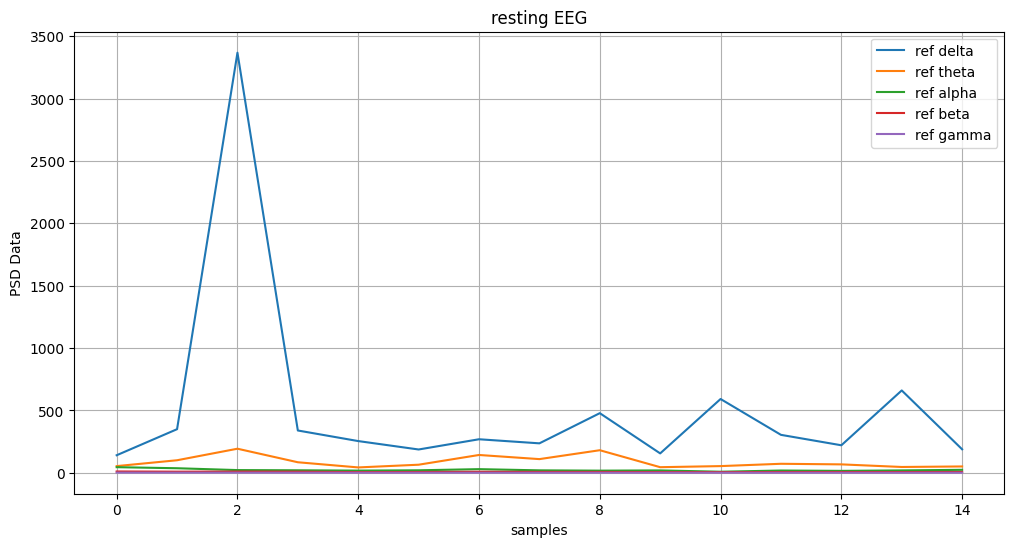

In [9]:
x_ref = range(sample_no)

# Plotting the EEG signal
plt.figure(figsize=(12, 6))
plt.plot(x_ref, ref_waves[0,:], label='ref delta')
plt.plot(x_ref, ref_waves[1,:], label='ref theta')
plt.plot(x_ref, ref_waves[2,:], label='ref alpha')
plt.plot(x_ref, ref_waves[3,:], label='ref beta')
plt.plot(x_ref, ref_waves[4,:], label='ref gamma')
plt.xlabel('samples')
plt.ylabel('PSD Data')
plt.title('resting EEG')
plt.legend()
plt.grid(True)
plt.show()

**Step 7: Alternative scenario processing**
Repeat this process with the second provided dataset, which is taken while the subject is engaged with a comedic video designed to elicit laughter and active facial expression responses.
Make sure to discuss the final brain wave PSD plots of this data as well.

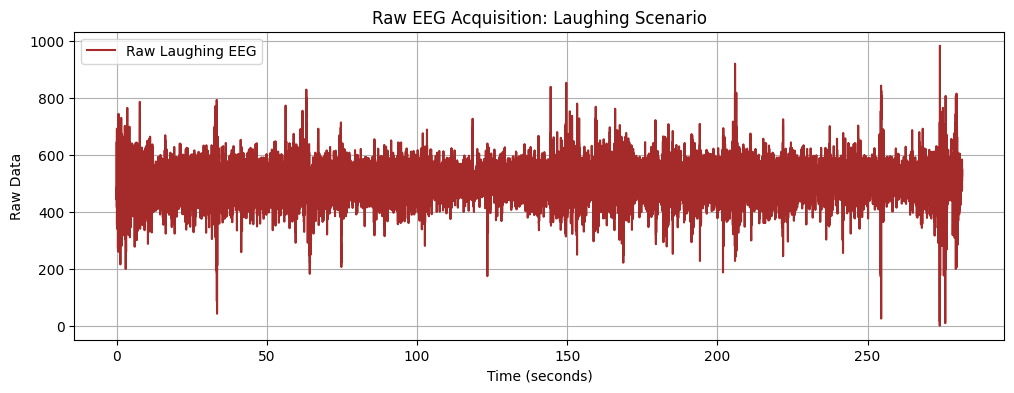

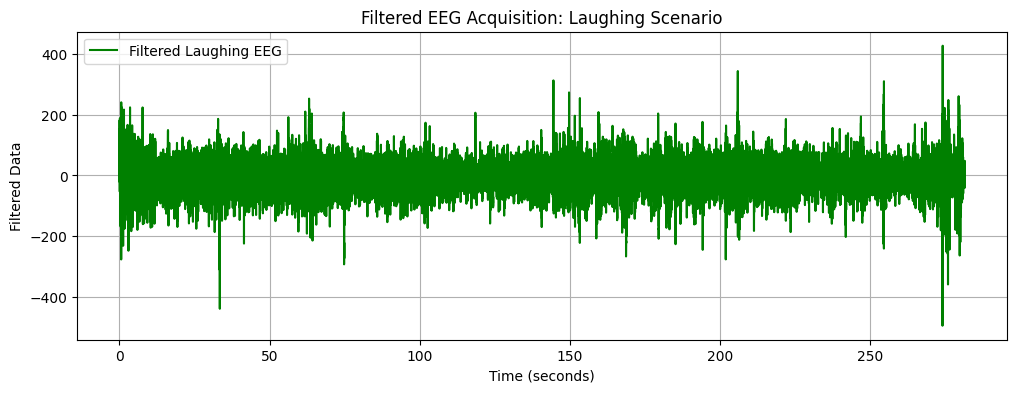

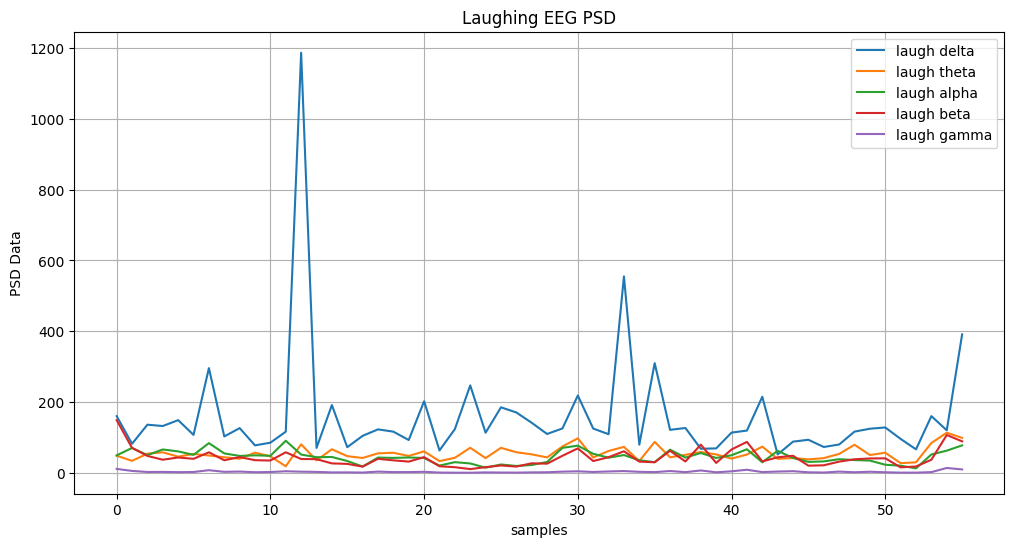

In [10]:
# TODO: Repeat the same processing with the other dataset
# Make sure to change the name of storage variable to something else

raw_laugh = np.genfromtxt('EEG_laugh.txt', usecols=5)
raw_laugh = raw_laugh[np.isfinite(raw_laugh)]
time_laugh = np.arange(len(raw_laugh)) / fs
plt.figure(figsize=(12, 4))
plt.plot(time_laugh, raw_laugh, label='Raw Laughing EEG', color='brown')
plt.xlabel('Time (seconds)')
plt.ylabel('Raw Data')
plt.title('Raw EEG Acquisition: Laughing Scenario')
plt.legend()
plt.grid(True)
plt.show()

filtered_laugh = bandpass_filter(raw_laugh, lowcut, highcut, fs)
plt.figure(figsize=(12, 4))
plt.plot(time_laugh, filtered_laugh, label='Filtered Laughing EEG', color='green')
plt.xlabel('Time (seconds)')
plt.ylabel('Filtered Data')
plt.title('Filtered EEG Acquisition: Laughing Scenario')
plt.legend()
plt.grid(True)
plt.show()

laugh_sample_no = len(filtered_laugh) // sample_len
laugh_waves = np.zeros((5, laugh_sample_no))

for i in range(laugh_sample_no):
    start_ind = i * sample_len
    end_ind = start_ind + sample_len
    sample = filtered_laugh[start_ind:end_ind]
    f, P = signal.welch(sample, fs, nperseg=fs*2)

    d_P = np.mean(P[np.where((f >= d_band[0]) & (f <= d_band[1]))])
    t_P = np.mean(P[np.where((f >= t_band[0]) & (f <= t_band[1]))])
    a_P = np.mean(P[np.where((f >= a_band[0]) & (f <= a_band[1]))])
    b_P = np.mean(P[np.where((f >= b_band[0]) & (f <= b_band[1]))])
    g_P = np.mean(P[np.where((f >= g_band[0]) & (f <= g_band[1]))])

    laugh_waves[0,i] = d_P
    laugh_waves[1,i] = t_P
    laugh_waves[2,i] = a_P
    laugh_waves[3,i] = b_P
    laugh_waves[4,i] = g_P

plt.figure(figsize=(12, 6))
plt.plot(laugh_waves[0,:], label='laugh delta')
plt.plot(laugh_waves[1,:], label='laugh theta')
plt.plot(laugh_waves[2,:], label='laugh alpha')
plt.plot(laugh_waves[3,:], label='laugh beta')
plt.plot(laugh_waves[4,:], label='laugh gamma')
plt.xlabel('samples')
plt.ylabel('PSD Data')
plt.title('Laughing EEG PSD')
plt.legend()
plt.grid(True)
plt.show()

**Step 8: Comparison of two scenarios**
Plot and compare each brain wave frequencies of the two scenarios. You should be able to notice the increased volatility of certain brain waves in the laughing scenario. Discuss the potential reasons. [Hint: think about what the electrodes are also collecting while taking the forehead EEG. ]

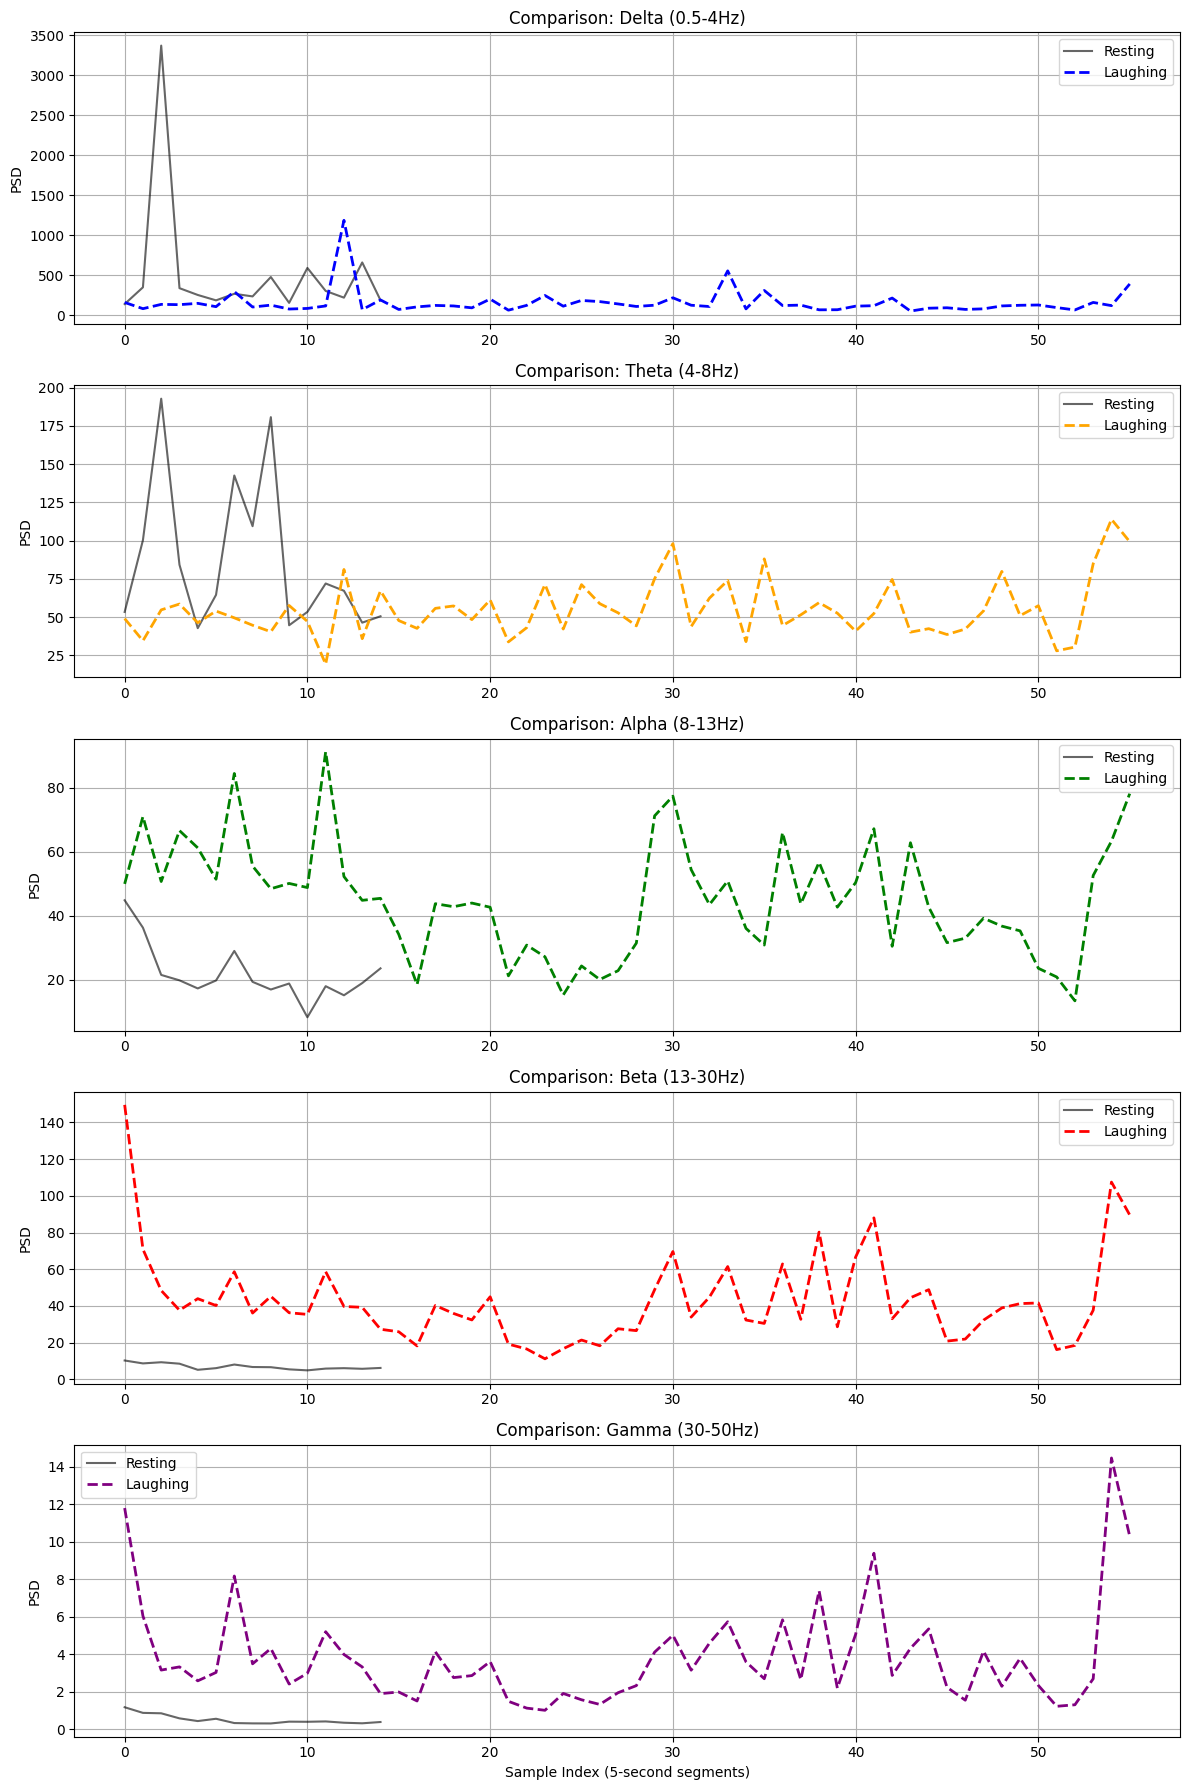

In [11]:
# TODO: Compare the PSD of corresponding brainwaves by plotting them together
fig, axes = plt.subplots(5, 1, figsize=(12, 18))
bands = ['Delta (0.5-4Hz)', 'Theta (4-8Hz)', 'Alpha (8-13Hz)', 'Beta (13-30Hz)', 'Gamma (30-50Hz)']
colors = ['blue', 'orange', 'green', 'red', 'purple']

for i in range(5):
    axes[i].plot(ref_waves[i, :], label='Resting', color='black', alpha=0.6, linewidth=1.5)
    axes[i].plot(laugh_waves[i, :], label='Laughing', color=colors[i], linestyle='--', linewidth=2)
    axes[i].set_title(f'Comparison: {bands[i]}')
    axes[i].set_ylabel('PSD')
    axes[i].legend()
    axes[i].grid(True)
plt.xlabel('Sample Index (5-second segments)')
plt.tight_layout()
plt.show()